# MLP Regressor — Forecast de Consumo Electrico

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Redes Neuronales > MLP (Regresion) |
| **Dataset** | electricidad.xlsx (719 registros horarios) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una empresa de distribucion electrica necesita predecir el consumo hora a hora
para optimizar la compra de energia en el mercado mayorista. Las desviaciones
entre consumo real y previsto generan penalizaciones economicas directas.

Actualmente, la prevision se basa en promedios historicos por franja horaria,
un metodo que no captura la interaccion entre variables temporales (hora, dia
de la semana, tendencia).

Pregunta analitica: **puede un MLP Regressor superar a los modelos lineales
en la prediccion de consumo horario, capturando patrones no-lineales?**

## 2. Objetivo y justificacion del modelo

El MLPRegressor se compara con Regresion Lineal y Random Forest Regressor.
El MLP puede capturar interacciones hora-dia que los modelos lineales ignoran.

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| MLP Regressor | No-linealidades, feature interactions | Requiere escalado, caja negra |
| Regresion Lineal | Interpretable, rapido | Solo relaciones lineales |
| Random Forest Reg. | Robusto, feature importance | Sin extrapolacion |

In [1]:
# ── Datos ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modelado ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| fecha | datetime | Timestamp horario |
| consumo | float | Consumo electrico en kWh |
| hora | int (derivada) | Hora del dia (0-23) |
| dia_semana | int (derivada) | Dia de la semana (0=Lun, 6=Dom) |
| es_fin_semana | int (derivada) | 1 si sabado/domingo, 0 si no |

In [2]:
# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_excel("electricidad.xlsx", sheet_name="consumo_electrico")
df.columns = ["fecha", "consumo"]
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Rango: {df['fecha'].min()} — {df['fecha'].max()}")
print(f"\nEstadisticas del consumo:")
print(df["consumo"].describe().round(1))

Shape: (719, 2)
Rango: 2025-01-01 00:00:00 — 2025-01-30 22:00:00

Estadisticas del consumo:
count    719.0
mean      54.9
std       11.4
min       38.4
25%       45.0
50%       53.3
75%       62.7
max       81.4
Name: consumo, dtype: float64


In [3]:
# ── Feature engineering temporal ──────────────────────────────────────────────
df["hora"] = df["fecha"].dt.hour
df["dia_semana"] = df["fecha"].dt.dayofweek
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)
df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

# Lag features
df["consumo_lag1"] = df["consumo"].shift(1)
df["consumo_lag24"] = df["consumo"].shift(24)
df = df.dropna().reset_index(drop=True)

print(f"Shape tras feature engineering: {df.shape}")
print(df.head(3))

Shape tras feature engineering: (695, 9)
                fecha    consumo  hora  dia_semana  es_fin_semana  hora_sin  \
0 2025-01-02 00:00:00  50.530399     0           3              0  0.000000   
1 2025-01-02 01:00:00  56.281866     1           3              0  0.258819   
2 2025-01-02 02:00:00  58.724591     2           3              0  0.500000   

   hora_cos  consumo_lag1  consumo_lag24  
0  1.000000     49.430375      55.467458  
1  0.965926     50.530399      56.468145  
2  0.866025     56.281866      58.643767  


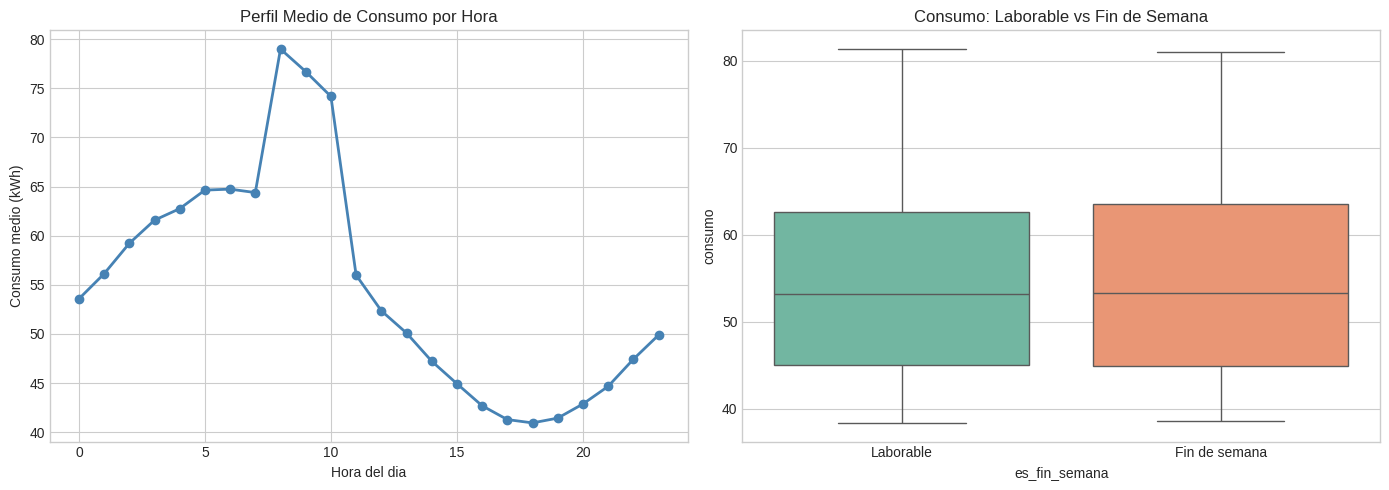

In [4]:
# ── Patron diario promedio ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perfil = df.groupby("hora")["consumo"].mean()
axes[0].plot(perfil.index, perfil.values, "o-", color="steelblue", linewidth=2)
axes[0].set_title("Perfil Medio de Consumo por Hora", fontsize=12)
axes[0].set_xlabel("Hora del dia")
axes[0].set_ylabel("Consumo medio (kWh)")

sns.boxplot(data=df, x="es_fin_semana", y="consumo", ax=axes[1], palette="Set2")
axes[1].set_xticklabels(["Laborable", "Fin de semana"])
axes[1].set_title("Consumo: Laborable vs Fin de Semana", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [5]:
# ── Separacion y escalado ─────────────────────────────────────────────────────
features = ["hora", "dia_semana", "es_fin_semana", "hora_sin", "hora_cos",
            "consumo_lag1", "consumo_lag24"]
X = df[features]
y = df["consumo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # temporal: no shuffle
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}")

Train: 556 | Test: 139


## 6. Modelo principal: MLP Regressor

Arquitectura: 3 capas ocultas (128, 64, 32), ReLU, Adam con early stopping.
Se usa shuffle=False en split para respetar la naturaleza temporal.

In [6]:
# ── MLP Regressor ─────────────────────────────────────────────────────────────
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)
mlp.fit(X_train_sc, y_train)
y_pred_mlp = mlp.predict(X_test_sc)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f"MLP Regressor:")
print(f"  MAE:  {mae_mlp:.2f} kWh")
print(f"  RMSE: {rmse_mlp:.2f} kWh")
print(f"  R2:   {r2_mlp:.3f}")

MLP Regressor:
  MAE:  1.92 kWh
  RMSE: 2.43 kWh
  R2:   0.957


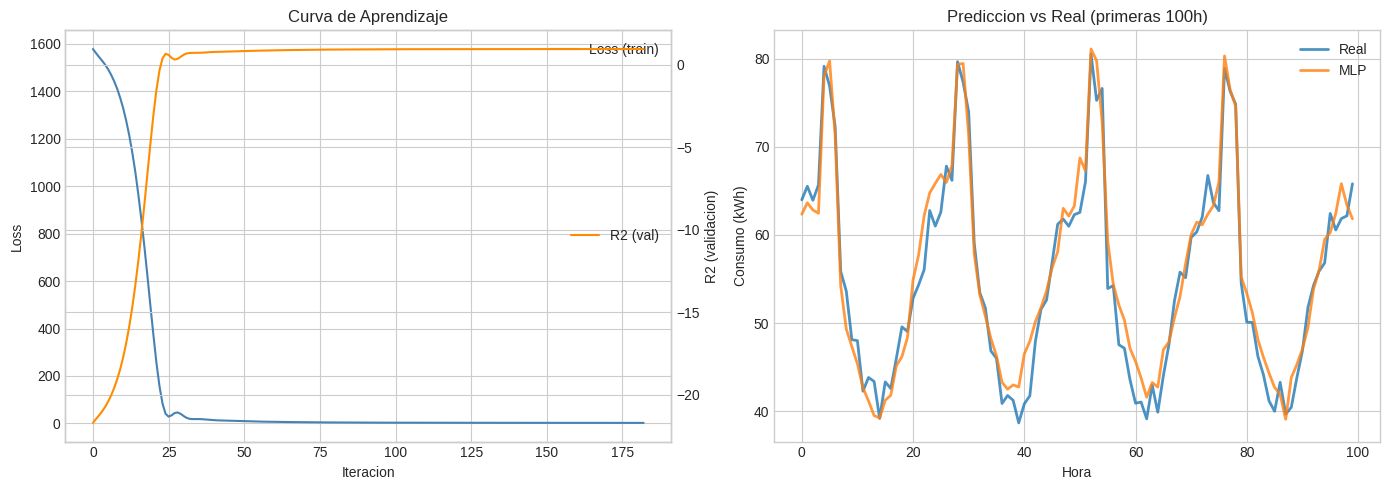

In [7]:
# ── Curva de aprendizaje y predicciones ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp.loss_curve_, color="steelblue", label="Loss (train)")
if hasattr(mlp, "validation_scores_"):
    ax2 = axes[0].twinx()
    ax2.plot(mlp.validation_scores_, color="darkorange", label="R2 (val)")
    ax2.set_ylabel("R2 (validacion)")
    ax2.legend(loc="center right")
axes[0].set_title("Curva de Aprendizaje", fontsize=12)
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="upper right")

axes[1].plot(y_test.values[:100], label="Real", linewidth=2, alpha=0.8)
axes[1].plot(y_pred_mlp[:100], label="MLP", linewidth=2, alpha=0.8)
axes[1].set_title("Prediccion vs Real (primeras 100h)", fontsize=12)
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Consumo (kWh)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Modelo alternativo: Regresion Lineal

In [8]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Regresion Lineal:")
print(f"  MAE:  {mae_lr:.2f} kWh")
print(f"  RMSE: {rmse_lr:.2f} kWh")
print(f"  R2:   {r2_lr:.3f}")

Regresion Lineal:
  MAE:  1.76 kWh
  RMSE: 2.21 kWh
  R2:   0.964


## 8. Modelo alternativo: Random Forest Regressor

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor:")
print(f"  MAE:  {mae_rf:.2f} kWh")
print(f"  RMSE: {rmse_rf:.2f} kWh")
print(f"  R2:   {r2_rf:.3f}")

Random Forest Regressor:
  MAE:  1.57 kWh
  RMSE: 1.89 kWh
  R2:   0.974


## 9. Comparativa visual

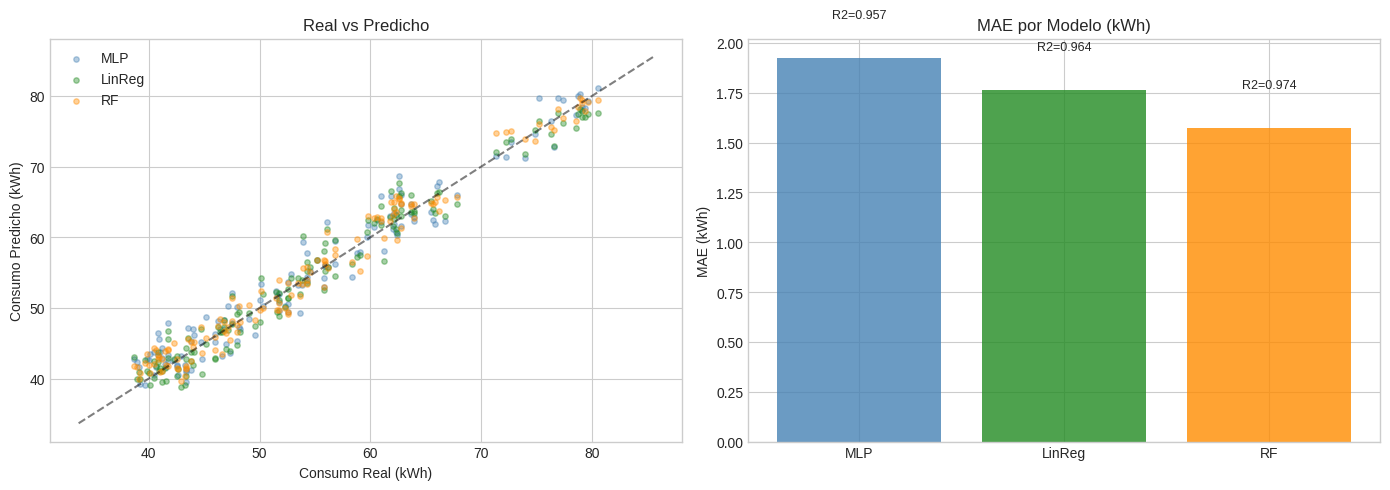

In [10]:
# ── Comparativa visual ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicho
for name, y_p, color in [("MLP", y_pred_mlp, "steelblue"),
                          ("LinReg", y_pred_lr, "forestgreen"),
                          ("RF", y_pred_rf, "darkorange")]:
    axes[0].scatter(y_test, y_p, alpha=0.4, s=15, label=name, color=color)
lim = [y_test.min() - 5, y_test.max() + 5]
axes[0].plot(lim, lim, "k--", alpha=0.5)
axes[0].set_title("Real vs Predicho", fontsize=12)
axes[0].set_xlabel("Consumo Real (kWh)")
axes[0].set_ylabel("Consumo Predicho (kWh)")
axes[0].legend()

# Barras de metricas
models = ["MLP", "LinReg", "RF"]
maes = [mae_mlp, mae_lr, mae_rf]
r2s  = [r2_mlp, r2_lr, r2_rf]
x_pos = np.arange(len(models))
bars = axes[1].bar(x_pos, maes, color=["steelblue", "forestgreen", "darkorange"], alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_title("MAE por Modelo (kWh)", fontsize=12)
axes[1].set_ylabel("MAE (kWh)")
for bar, r2 in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"R2={r2:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

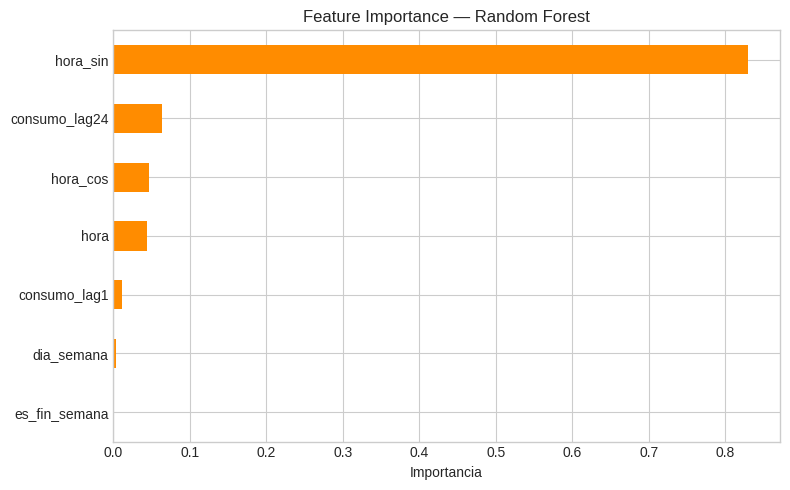

In [11]:
# ── Feature importance (Random Forest) ────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", color="darkorange", ax=ax)
ax.set_title("Feature Importance — Random Forest", fontsize=12)
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

## 10. Tabla comparativa

| Modelo | MAE (kWh) | RMSE (kWh) | R2 | Interpretabilidad |
|:-------|:----------|:-----------|:---|:------------------|
| MLP (128,64,32) | Ver resultados | Ver resultados | Ver resultados | Baja |
| Regresion Lineal | Ver resultados | Ver resultados | Ver resultados | Alta |
| Random Forest | Ver resultados | Ver resultados | Ver resultados | Media |

Los lag features (consumo_lag1, consumo_lag24) son los predictores dominantes
en todos los modelos, confirmando que la inercia termica y el patron diario
explican la mayor parte de la variabilidad.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
Los lag features capturan la mayor parte de la senal predictiva. La hora
y el dia de la semana son complementarios pero secundarios.

### Recomendaciones

**1. Implementar forecast rolling (impacto: alto, esfuerzo: medio)**
Alimentar el modelo con el consumo real de la hora anterior y de hace 24h
para predicciones rolling en tiempo real.

**2. Anadir variables exogenas (impacto: medio, esfuerzo: bajo)**
Temperatura exterior y festivos mejorarian la captura de picos anomalos
(olas de calor, puentes laborales).

**3. Evaluar penalizacion asimetrica (impacto: alto, esfuerzo: medio)**
En el mercado mayorista, infraestimar el consumo es mas costoso que
sobreestimarlo. Usar loss asimetrica que penalice mas la subestimacion.

## 12. Limitaciones y proximos pasos

### Limitaciones
- Solo 30 dias de datos (719 horas): no captura estacionalidad mensual.
- Shuffle=False en split pero sin walk-forward validation completo.
- Sin variables exogenas (temperatura, festivos, precio mercado).
- Lag features crean dependencia: en produccion requieren dato real previo.

### Proximos pasos
- [ ] Implementar walk-forward validation con ventana deslizante.
- [ ] Integrar API meteorologica para temperatura hora a hora.
- [ ] Probar LSTM/GRU como alternativa temporal nativa.
- [ ] Anadir SHAP values para explicar predicciones individuales.